In [1]:
!pip install -q pandas numpy matplotlib seaborn plotly scipy

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import kruskal

plt.style.use("ggplot")
sns.set_palette("Set2")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (1).csv
Saving historical_data.csv to historical_data (1).csv


In [4]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [5]:
print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

trades.head()

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [9]:
print(trades.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [10]:
print(sentiment.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [11]:
trades = trades.drop_duplicates()

sentiment = sentiment.drop_duplicates()

In [13]:
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="mixed",
    dayfirst=True
)

sentiment["date"] = pd.to_datetime(sentiment["date"])

In [18]:
trades["date"] = trades["Timestamp IST"].dt.date

In [19]:
print("date" in trades.columns)
print(trades[["Timestamp IST", "date"]].head())

True
        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [21]:

trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    format="mixed",
    errors="coerce"
)


trades["date"] = trades["Timestamp IST"].dt.normalize()

sentiment["date"] = pd.to_datetime(sentiment["date"], errors="coerce").dt.normalize()

In [22]:
print(trades["date"].dtype)
print(sentiment["date"].dtype)

datetime64[ns]
datetime64[ns]


In [23]:
merged = pd.merge(
    trades,
    sentiment,
    on="date",
    how="left"
)

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [24]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [25]:
merged.describe(include='all')

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05,211224,2.112180e+05,211218.000000,211218
unique,32,246,NaN,NaN,NaN,2,NaN,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,5
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,NaN,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,Fear
freq,40184,68005,NaN,NaN,NaN,108528,NaN,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN,NaN,NaN,NaN,61837
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,2025-01-31 12:04:22.915009792,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12,2025-01-30 23:54:28.674013952,1.738301e+09,51.649656,NaN
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,2023-05-01 01:06:00,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12,2023-05-01 00:00:00,1.682919e+09,10.000000,NaN
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,2024-12-31 21:00:45,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12,2024-12-31 00:00:00,1.735623e+09,33.000000,NaN
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,2025-02-24 18:55:00,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12,2025-02-24 00:00:00,1.740375e+09,49.000000,NaN
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,2025-04-02 18:22:00,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12,2025-04-02 00:00:00,1.743572e+09,72.000000,NaN
max,NaN,NaN,109004.000000,1.582244e+07,3.921431e+06,NaN,2025-05-01 12:13:00,3.050948e+07,NaN,135329.090100,NaN,9.014923e+10,NaN,837.471593,1.130000e+15,1.750000e+12,2025-05-01 00:00:00,1.746077e+09,94.000000,NaN


In [26]:
merged.shape

(211224, 20)

In [27]:
merged["classification"].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


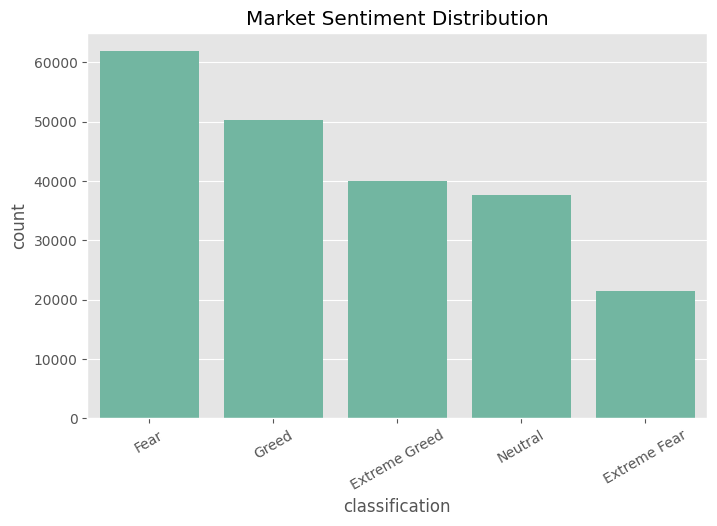

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.xticks(rotation=30)

plt.title("Market Sentiment Distribution")

plt.show()

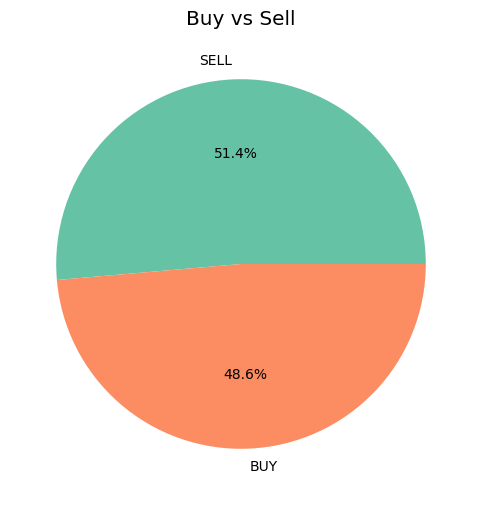

In [29]:
plt.figure(figsize=(6,6))

merged["Side"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Buy vs Sell")

plt.show()

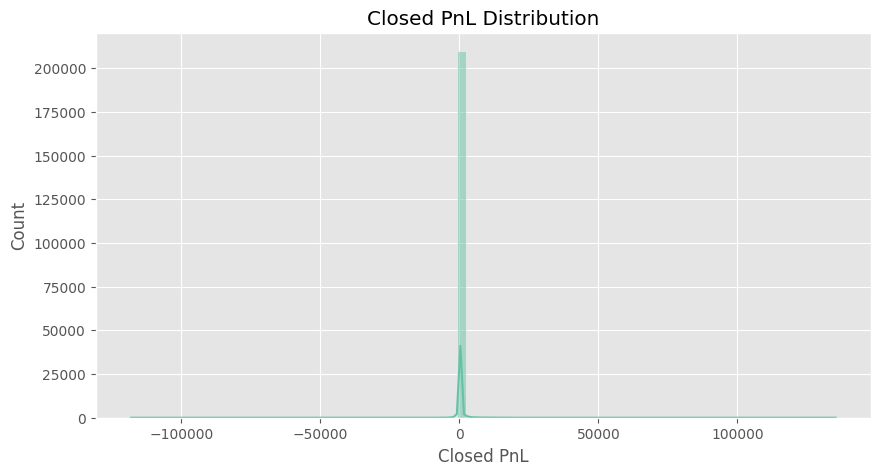

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged["Closed PnL"],
    bins=80,
    kde=True
)

plt.title("Closed PnL Distribution")

plt.show()

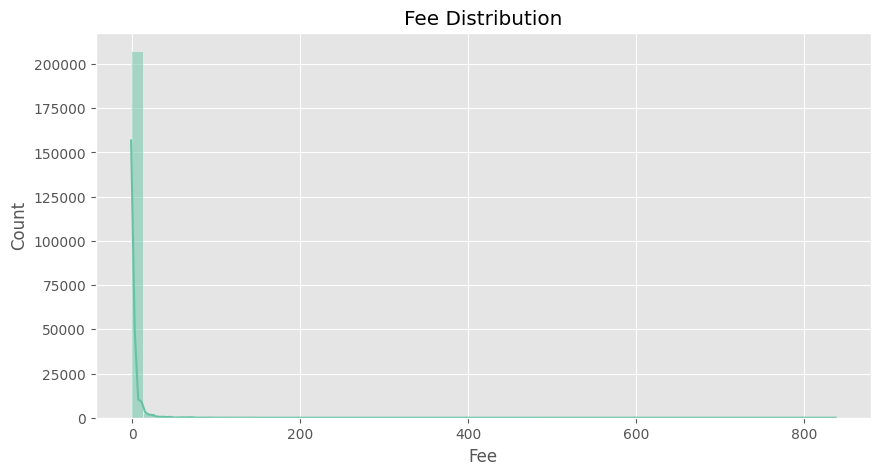

In [31]:
plt.figure(figsize=(10,5))

sns.histplot(
    merged["Fee"],
    bins=60,
    kde=True
)

plt.title("Fee Distribution")

plt.show()

In [32]:
avg_pnl = merged.groupby("classification")["Closed PnL"].mean().sort_values()

avg_pnl

,Closed PnL
classification,
Neutral,34.307718
Extreme Fear,34.537862
Greed,42.743559
Fear,54.290400
Extreme Greed,67.892861


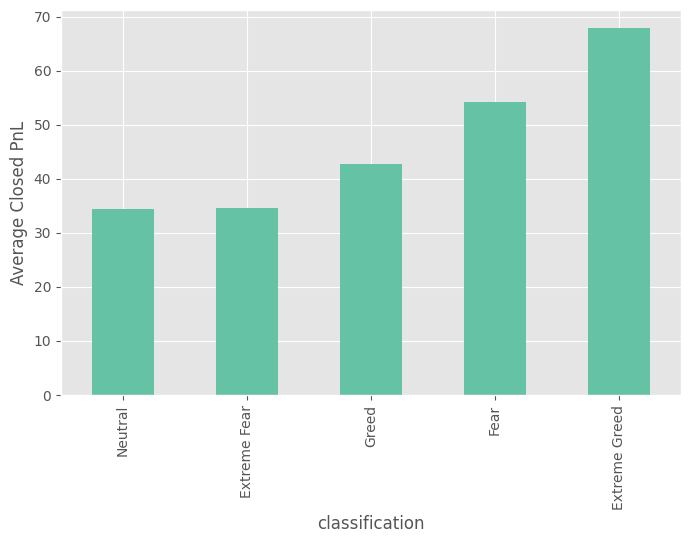

In [33]:
plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.ylabel("Average Closed PnL")

plt.show()

In [34]:
merged.groupby("classification")["Closed PnL"].median()

,Closed PnL
classification,
Extreme Fear,0.0
Extreme Greed,0.0
Fear,0.0
Greed,0.0
Neutral,0.0


In [35]:
merged.groupby("classification")["Closed PnL"].max()

,Closed PnL
classification,
Extreme Fear,115287.00000
Extreme Greed,44223.45187
Fear,135329.09010
Greed,74530.52371
Neutral,48504.09555


In [36]:
merged.groupby("classification")["Closed PnL"].min()

,Closed PnL
classification,
Extreme Fear,-31036.69194
Extreme Greed,-10259.46800
Fear,-35681.74723
Greed,-117990.10410
Neutral,-24500.00000


In [37]:
merged["Winning"] = merged["Closed PnL"] > 0

In [38]:
win_rate = merged.groupby("classification")["Winning"].mean()*100

win_rate

,Winning
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


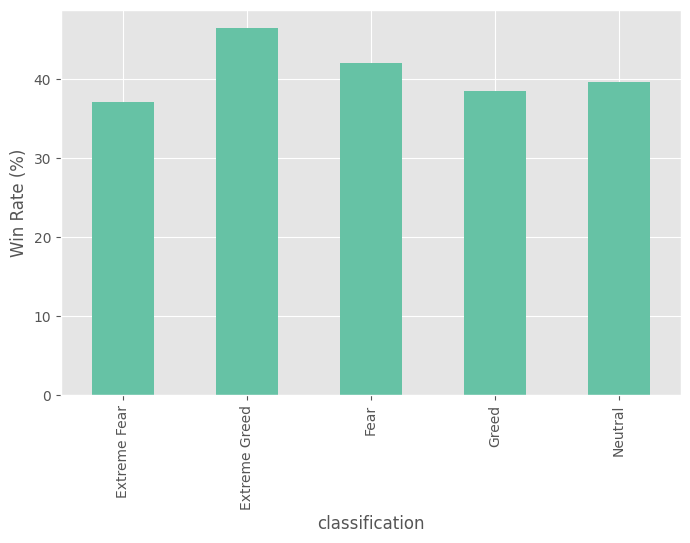

In [39]:
plt.figure(figsize=(8,5))

win_rate.plot(kind="bar")

plt.ylabel("Win Rate (%)")

plt.show()

In [40]:
merged.groupby("classification")["Size USD"].mean()

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


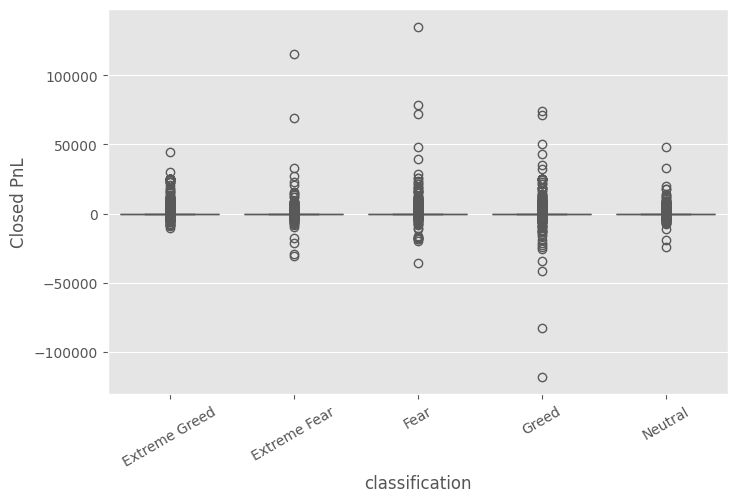

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.xticks(rotation=30)

plt.show()

In [42]:
numeric = merged.select_dtypes(include=np.number)

corr = numeric.corr()

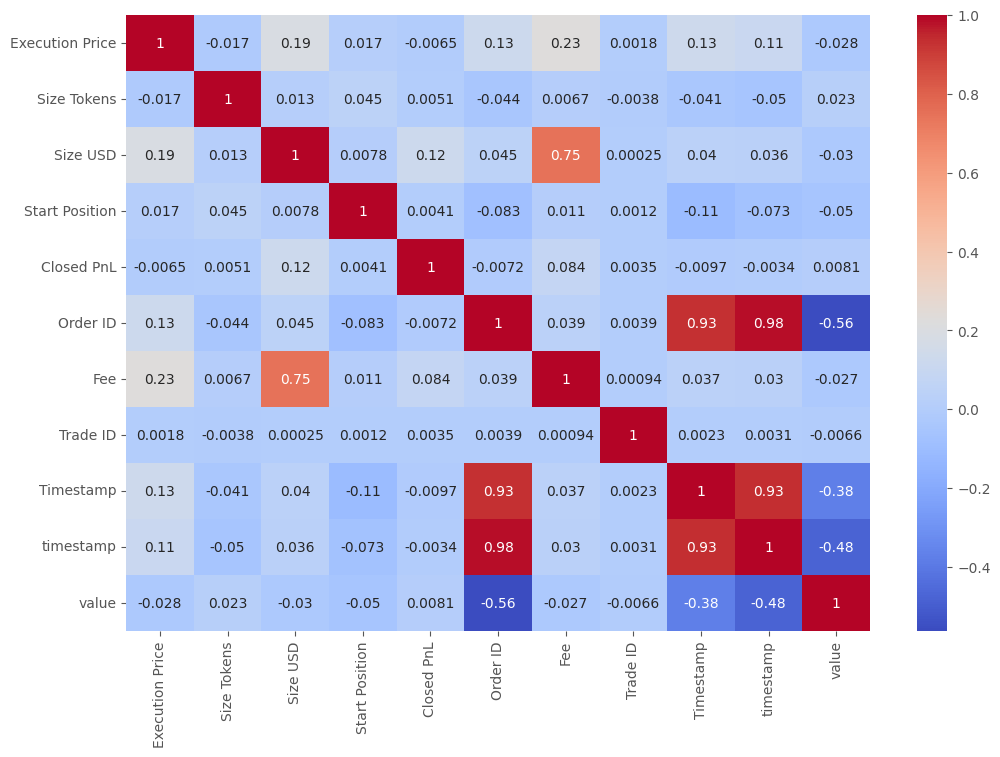

In [43]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

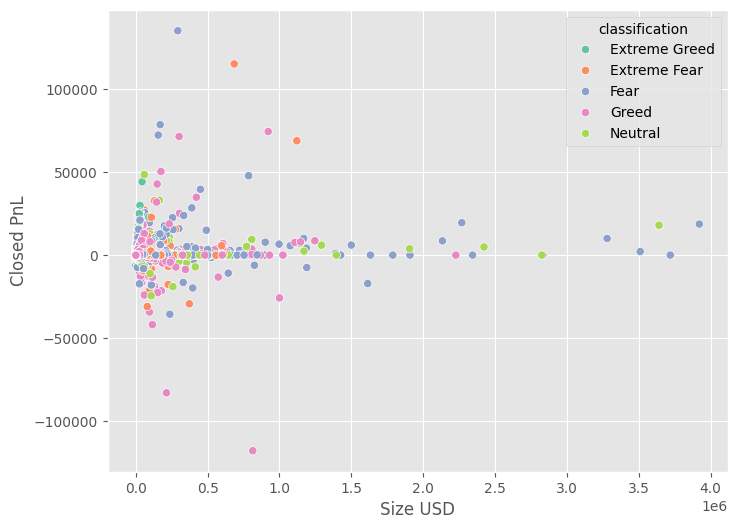

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged,
    x="Size USD",
    y="Closed PnL",
    hue="classification"
)

plt.show()

In [45]:
merged.groupby("Coin")["Closed PnL"].mean().sort_values(ascending=False)

,Closed PnL
Coin,
@109,270.704207
AVAX,239.095613
ENA,219.524751
@85,200.804091
EIGEN,197.063189
...,...
S,-60.033651
IO,-62.198609
@147,-70.126539


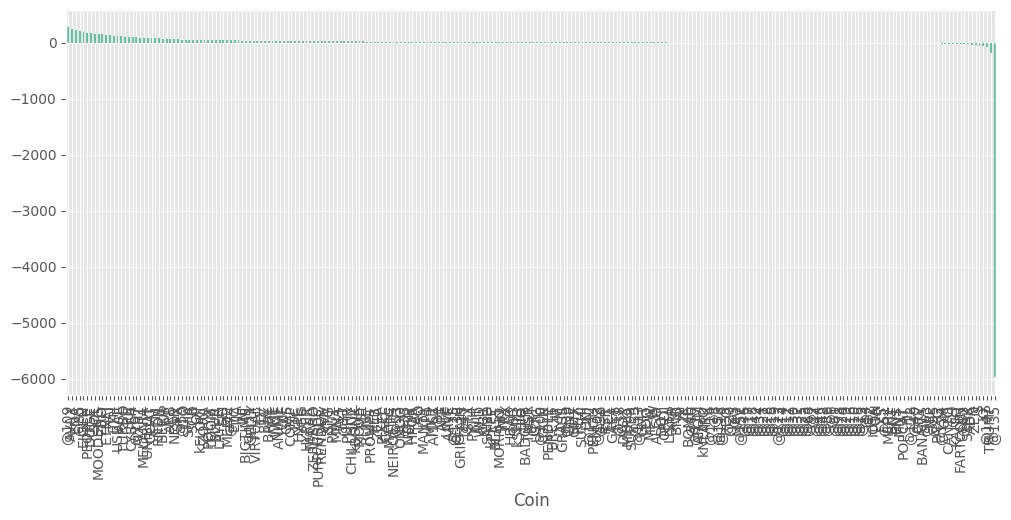

In [46]:
coin_pnl = merged.groupby("Coin")["Closed PnL"].mean().sort_values(ascending=False)

coin_pnl.plot(kind="bar", figsize=(12,5))
plt.show()

In [47]:
groups = []

for name, grp in merged.groupby("classification"):
    groups.append(grp["Closed PnL"])

kruskal(*groups)

KruskalResult(statistic=np.float64(1226.9955994737047), pvalue=np.float64(2.2377483557731266e-264))

In [48]:
merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,4.030115e+05


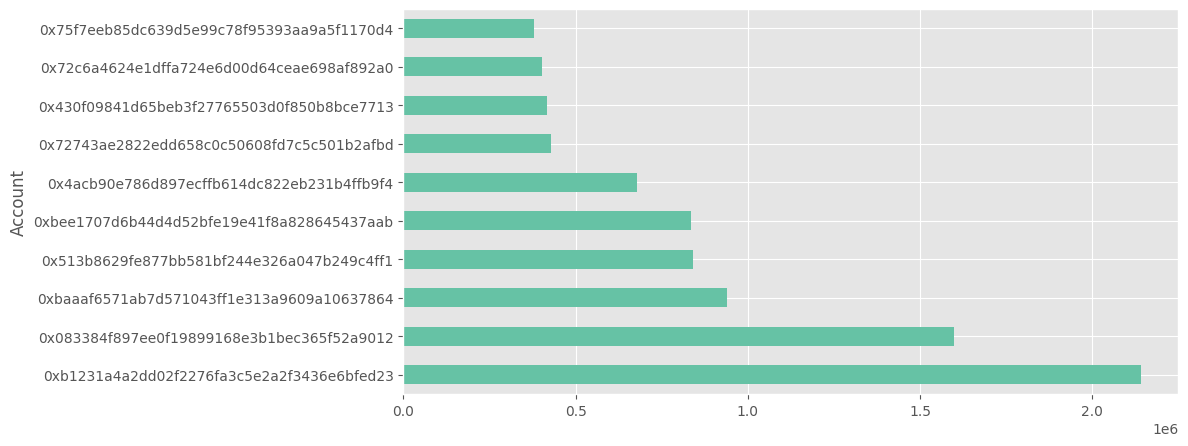

In [49]:
top = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

top.plot(kind="barh", figsize=(10,5))
plt.show()

In [50]:
merged.to_csv("merged_dataset.csv", index=False)

In [51]:
from google.colab import files

files.download("merged_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>